In [1]:
# Installing timm (PyTorch Image Models) for our 1-channel architecture
!pip install timm -q

In [2]:
import os
import numpy as np
import torch
import glob
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
from tqdm import tqdm
import timm  
from collections import OrderedDict
import copy

torch.manual_seed(42)
np.random.seed(42)

NUM_CLASSES = 3
BATCH_SIZE = 256  
MAX_LR = 3e-3     
NUM_EPOCHS = 20   
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"INFO: Initializing Pipeline on {DEVICE}")

INFO: Initializing Pipeline on cuda


In [3]:
class DeepLenseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                for file_path in glob.glob(os.path.join(class_dir, "*.npy")):
                    self.samples.append((file_path, self.class_to_idx[class_name]))
    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path)
        
        # Convert to tensor
        image = torch.from_numpy(image).float()
        
        # Safe ensure shape is (1, H, W). 
        if image.dim() == 2:
            image = image.unsqueeze(0)
        
        if self.transform:
            image = self.transform(image)
                    
        return image, label

# Adding Dihedral Symmetry 
transform = {
    "train": transforms.Compose([
        transforms.Resize(224, antialias=True),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.Normalize(mean=[0.5], std=[0.5]) 
    ]),
    "val": transforms.Compose([
        transforms.Resize(224, antialias=True),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
}

import copy

def load_data(data_dir):
    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'val') 
    
    full_train_dataset = DeepLenseDataset(train_dir, transform=transform['train'])
    test_dataset = DeepLenseDataset(val_dir, transform=transform['val'])

    # (90/10)% Split
    train_size = int(len(full_train_dataset) * 0.9)
    val_size = len(full_train_dataset) - train_size

    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    # THE FIX: Safely decouple the validation dataset memory before changing transforms
    val_dataset.dataset = copy.deepcopy(full_train_dataset)
    val_dataset.dataset.transform = transform['val']
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    
    return train_loader, val_loader, test_loader, full_train_dataset.class_to_idx

In [4]:
# Training block
def initialize_model():
    model = timm.create_model('resnet34', pretrained=True, in_chans=1, num_classes=NUM_CLASSES)
    return model

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    model.to(DEVICE)
    scaler = torch.amp.GradScaler('cuda')
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            scheduler.step()
            
            running_loss += loss.item() * inputs.size(0)
            train_pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.6f}"})
        
        epoch_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        
        # Validation Phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_correct / val_total
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)
        
        print(f'Epoch {epoch+1}: Train Loss={epoch_loss:.4f} | Val Loss={val_epoch_loss:.4f} | Val Acc={val_epoch_acc:.4f}')
        
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            torch.save(model.state_dict(), 'best_timm_resnet34.pt')
            print(f'INFO: New best model saved (Validation Accuracy: {best_val_acc:.4f})')
            
    return model, history

In [5]:
# Execution Block
data_dir = '/kaggle/input/datasets/stallio/classification-dataset/dataset'  

train_loader, val_loader, test_loader, class_to_idx = load_data(data_dir)

model = initialize_model()
model = torch.compile(model, mode="reduce-overhead") 

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR, 
    steps_per_epoch=len(train_loader), 
    epochs=NUM_EPOCHS
)

print("\nINFO: Commencing Training Pipeline :)")
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, NUM_EPOCHS)

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


INFO: Commencing Training Pipeline :)


Epoch 1/20 [Train]:   0%|          | 0/106 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()
W0325 17:14:18.385000 24 torch/_inductor/utils.py:1558] [0/0] Not enough SMs to use max_autotune_gemm mode
Epoch 1/20 [Val]: 100%|██████████| 12/12 [00:20<00:00,  1.68s/it]


Epoch 1: Train Loss=1.0984 | Val Loss=1.0947 | Val Acc=0.3677
INFO: New best model saved (Validation Accuracy: 0.3677)


Epoch 2/20 [Val]: 100%|██████████| 12/12 [00:02<00:00,  4.08it/s]


...

Epoch 18: Train Loss=0.0478 | Val Loss=0.0997 | Val Acc=0.9673
INFO: New best model saved (Validation Accuracy: 0.9673)


Epoch 19/20 [Val]: 100%|██████████| 12/12 [00:02<00:00,  4.20it/s]


Epoch 19: Train Loss=0.0443 | Val Loss=0.1004 | Val Acc=0.9687
INFO: New best model saved (Validation Accuracy: 0.9687)


Epoch 20/20 [Val]: 100%|██████████| 12/12 [00:02<00:00,  4.22it/s]


Epoch 20: Train Loss=0.0407 | Val Loss=0.0999 | Val Acc=0.9690
INFO: New best model saved (Validation Accuracy: 0.9690)



INFO: Initiating final evaluation on test set...


Testing: 100%|██████████| 30/30 [00:18<00:00,  1.59it/s]


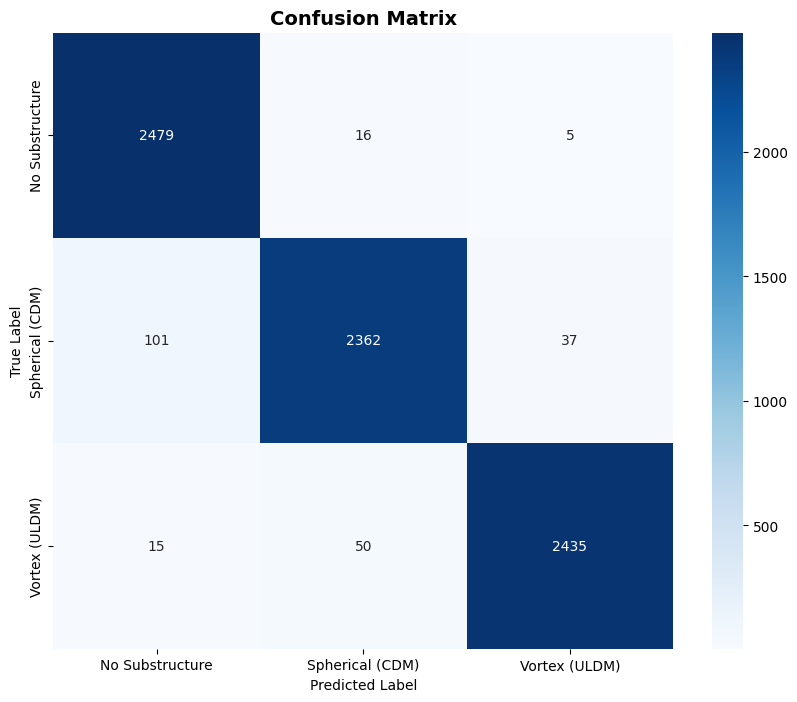

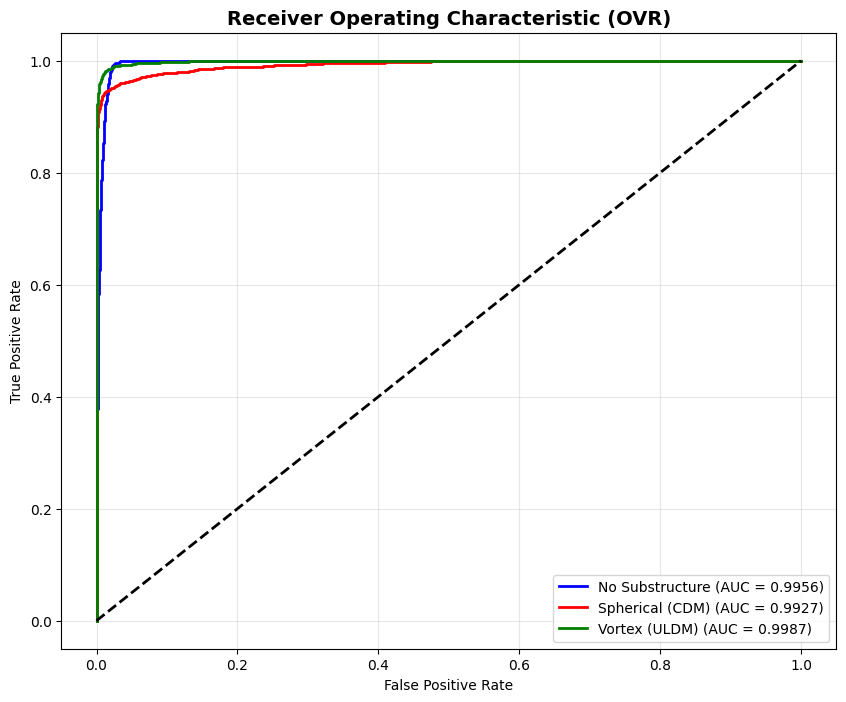


Evaluation Complete. Macro-Averaged OVR ROC AUC: 0.9957


In [6]:
# Evalution Block
print("\nINFO: Initiating final evaluation on test set...")

# Explicitly define classes to prevent NameError
CLASS_NAMES = ['No Substructure', 'Spherical (CDM)', 'Vortex (ULDM)']

# Initialize a clean model (no torch.compile artifacts)
eval_model = timm.create_model('resnet34', pretrained=False, in_chans=1, num_classes=NUM_CLASSES)

weights_path = 'best_timm_resnet34.pt' 
raw_state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)

clean_state_dict = OrderedDict()
for k, v in raw_state_dict.items():
    clean_state_dict[k.replace("_orig_mod.", "")] = v

eval_model.load_state_dict(clean_state_dict)
eval_model.to(DEVICE)
eval_model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = eval_model(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)  
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())  

all_labels_np = np.array(all_labels)
all_probs_np = np.array(all_probs)

# --- Plotting --_-
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(all_labels_np, all_preds), annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
roc_aucs = [] 

for i in range(len(CLASS_NAMES)):
    fpr, tpr, _ = roc_curve((all_labels_np == i).astype(int), all_probs_np[:, i])
    class_auc = auc(fpr, tpr)
    roc_aucs.append(class_auc) 
    plt.plot(fpr, tpr, lw=2, color=colors[i], label=f'{CLASS_NAMES[i]} (AUC = {class_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Receiver Operating Characteristic (OVR)', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Calculate and output the final metric
macro_roc_auc = sum(roc_aucs) / len(CLASS_NAMES)
print(f"\nEvaluation Complete. Macro-Averaged OVR ROC AUC: {macro_roc_auc:.4f}")